In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from itertools import combinations
from scipy.stats import ttest_ind
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import itertools

In [2]:
diamonds = sns.load_dataset('diamonds')

np.random.seed(42)
df = diamonds.sample(5000, random_state=42).copy()

print("Dataset Info:")
df.info()
print("\nValue Counts for Grouping Variable (cut):")
print(df['cut'].value_counts())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 1388 to 7126
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    5000 non-null   float64 
 1   cut      5000 non-null   category
 2   color    5000 non-null   category
 3   clarity  5000 non-null   category
 4   depth    5000 non-null   float64 
 5   table    5000 non-null   float64 
 6   price    5000 non-null   int64   
 7   x        5000 non-null   float64 
 8   y        5000 non-null   float64 
 9   z        5000 non-null   float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 328.1 KB

Value Counts for Grouping Variable (cut):
cut
Ideal        1953
Premium      1312
Very Good    1108
Good          465
Fair          162
Name: count, dtype: int64


In [3]:
groups = [group['price'].values for name, group in df.groupby('cut')]

f_stat, p_val = stats.f_oneway(*groups)

print(f"F-Statistic: {f_stat:.4f}")
print(f"P-value: {p_val:.4e}")

F-Statistic: 20.9836
P-value: 3.5595e-17


C:\Users\user\AppData\Local\Temp\ipykernel_7860\352971564.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group['price'].values for name, group in df.groupby('cut')]


Levene's Test Statistic: 18.0828, p-value: 9.3363e-15
Shapiro-Wilk Test Statistic: 0.8145, p-value: 3.5403e-60


C:\Users\user\AppData\Local\Temp\ipykernel_7860\1895699158.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['group_mean'] = df.groupby('cut')['price'].transform('mean')


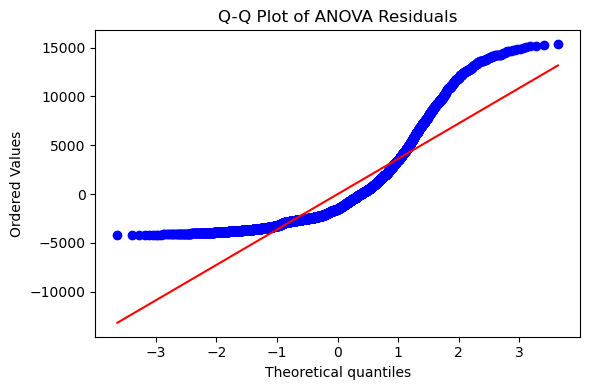

In [4]:
stat_levene, p_levene = stats.levene(*groups)
print(f"Levene's Test Statistic: {stat_levene:.4f}, p-value: {p_levene:.4e}")

df['group_mean'] = df.groupby('cut')['price'].transform('mean')
df['residuals'] = df['price'] - df['group_mean']

stat_shapiro, p_shapiro = stats.shapiro(df['residuals'])
print(f"Shapiro-Wilk Test Statistic: {stat_shapiro:.4f}, p-value: {p_shapiro:.4e}")

fig, ax = plt.subplots(figsize=(6, 4))
stats.probplot(df['residuals'], dist="norm", plot=ax)
ax.set_title("Q-Q Plot of ANOVA Residuals")
plt.tight_layout()
plt.savefig('qq_plot.png') # saving instead of plt.show()

     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
 group1   group2   meandiff p-adj    lower      upper   reject
--------------------------------------------------------------
   Fair      Good  -54.9562 0.9999 -1053.8717  943.9594  False
   Fair     Ideal -646.7067 0.2802 -1541.9179  248.5046  False
   Fair   Premium  619.1334 0.3433  -292.6744 1530.9412  False
   Fair Very Good  197.9385 0.9771  -723.0484 1118.9254  False
   Good     Ideal -591.7505 0.0347 -1156.7259  -26.7752   True
   Good   Premium  674.0896  0.016    83.1687 1265.0104   True
   Good Very Good  252.8946 0.7849  -352.0937  857.8829  False
  Ideal   Premium 1265.8401    0.0   874.9969 1656.6833   True
  Ideal Very Good  844.6452    0.0    432.842 1256.4483   True
Premium Very Good  -421.195 0.0756  -867.9298   25.5399  False
--------------------------------------------------------------


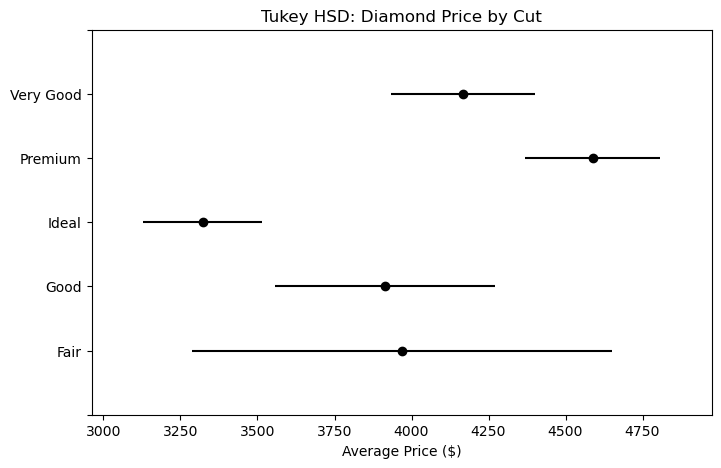

In [5]:
tukey = pairwise_tukeyhsd(endog=df['price'], groups=df['cut'], alpha=0.05)

print(tukey.summary())

fig = tukey.plot_simultaneous(figsize=(8, 5))
fig.axes[0].set_title("Tukey HSD: Diamond Price by Cut")
fig.axes[0].set_xlabel("Average Price ($)")
plt.savefig('tukey_plot.png')

All markdown questions' answers:


Null Hypothesis: The average price of diamonds is the same across all cut categories.


Alternative Hypothesis: At least one diamond cut category has a different average price.


Decision: Because the p-value is practically zero (well below α = 0.05), we reject the null hypothesis.


F-statistic: It indicates that the variance (average differences) between the different cut groups is significantly larger than the random variance within the groups themselves.


Equal-variance assumption: This assumption is not reasonable. The p-value from Levene's test is < 0.05, meaning the variances across the groups are significantly different.


Normality of residuals: The residuals do not look approximately normal; the Shapiro-Wilk p-value is < 0.05, and the Q-Q plot shows heavy deviations at the tails due to price skewness.


Alternatives: Because the assumptions are violated, you should use Welch's ANOVA (which corrects for unequal variances) or the Kruskal-Wallis H-test (a non-parametric alternative for non-normal data).


Significantly different pairs: Any pair with True in the Tukey table's reject column (e.g., Premium vs. Ideal) has significantly different means.


Not significantly different pairs: Any pair with False in the reject column is not significantly different.


Practical size: Yes, the confidence intervals are very helpful. They provide the actual dollar-value range of the difference between groups, allowing you to see if a statistically significant difference is large enough to actually matter in the real world.